# Large Scale Unsupervised Analysis of Cassini Spectra

This notebook applies our optimized Deep Learning pipeline to the large, **unlabelled** dataset `cda_qm_spectra_pre2008277_lvl1.parquet`.

### Strategy for Noisy, Unlabelled Data
Since we lack ground truth labels, we cannot use accuracy or confusion matrices. Instead, we rely on the Autoencoder's ability to **denoise** the data.

**The Pipeline:**
1.  **Preprocessing**: Log-transform and bin to 1000 length (handles dynamic range and varying input sizes).
2.  **1D Convolutional Autoencoder**: We use the CNN architecture which proved effective at learning "shift-invariant" features (shapes of peaks) while filtering out random noise.
3.  **Anomaly Detection via Reconstruction Error**: We will use the model's error to calculate a "Signal Quality Score". High error = Signal (complex structure), Low error = Noise (easy to predict flat line).
4.  **Latent Clustering**: We extract the compressed features and use clustering to discover *new* classes autonomously.

In [1]:

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# --- Configuration ---
# File Path for the new large, unlabelled dataset
DATA_FILE = '/Users/laibanajam/Downloads/cda_qm_spectra_pre2008277_lvl1.parquet'

Input_Length = 1000  # Standardized Bins
Batch_Size = 512     # Increased batch size for larger dataset
Learning_Rate = 1e-3
Epochs = 20          # Sufficient for initial convergence
Latent_Dim = 10      # Compressed feature size

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [2]:
# 1. Load Data
# Using chunks if necessary, but fast parquet reading is usually efficient
try:
    print(f"Loading {DATA_FILE}...")
    # Read only specific columns if possible to save memory, assuming 'spectrum' exists
    # If the file is extremely large, might need dask, but pandas often handles < 5GB fine
    df = pd.read_parquet(DATA_FILE)
    print(f"Dataset Shape: {df.shape}")
    
    if 'spectrum' not in df.columns:
        raise ValueError("Column 'spectrum' not found in dataset.")
        
    spectra_raw = np.stack(df['spectrum'].values)
    print("Spectra stacked into numpy array.")

except Exception as e:
    print(f"Error loading data: {e}")
    # Create dummy data if file access fails so notebook structure remains valid
    print("Creating dummy noise data for demonstration...")
    spectra_raw = np.random.rand(5000, 1000)
    df = pd.DataFrame({'spectrum': list(spectra_raw)})

# 2. Preprocessing Routine
def preprocess_spectra(spectra, target_length=1000):
    processed = []
    # Pre-allocate for speed? For now list append is robust for jagged arrays
    for spec in spectra:
        # Resize/Pad
        if len(spec) >= target_length:
            s = spec[:target_length]
        else:
            s = np.pad(spec, (0, target_length - len(spec)), 'constant')
        
        # Log Transform (Critical for dynamic range in Mass Spec)
        s = np.log1p(np.maximum(s, 0))
        
        # Max Normalization
        max_val = np.max(s)
        if max_val > 0:
            s = s / max_val
            
        processed.append(s)
    return np.array(processed, dtype=np.float32)

print("\nRunning Preprocessing (Log1p + Norm + Pad)...")
X_train = preprocess_spectra(spectra_raw, target_length=Input_Length)
print(f"Processed Data Shape: {X_train.shape}")

# Create DataLoader
tensor_x = torch.from_numpy(X_train).unsqueeze(1).to(device) # (N, 1, 1000)
loader = DataLoader(TensorDataset(tensor_x), batch_size=Batch_Size, shuffle=True)
print("DataLoader ready.")


Loading /Users/laibanajam/Downloads/cda_qm_spectra_pre2008277_lvl1.parquet...
Dataset Shape: (774953, 7)
Spectra stacked into numpy array.

Running Preprocessing (Log1p + Norm + Pad)...
Processed Data Shape: (774953, 1000)
DataLoader ready.


In [ ]:
# 3. Define 1D CNN Autoencoder
# Same successful architecture from previous experiments
class CDA_Autoencoder(nn.Module):
    def __init__(self, input_len=1000, latent_dim=10):
        super(CDA_Autoencoder, self).__init__()
        
        # Encoder: Compresses 1000 dim -> latent_dim
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=5, stride=2, padding=2),  # 1000 -> 500
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(32),
            nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2), # 500 -> 250
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(64),
            nn.Conv1d(64, 128, kernel_size=5, stride=2, padding=2), # 250 -> 125
            nn.LeakyReLU(0.2),
            nn.Flatten(),
            nn.Linear(128 * 125, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, latent_dim)
        )
        
        # Decoder: Reconstructs latent_dim -> 1000
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 128 * 125),
            nn.LeakyReLU(0.2)
        )
        
        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose1d(128, 64, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(64),
            nn.ConvTranspose1d(64, 32, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(32),
            nn.ConvTranspose1d(32, 1, kernel_size=5, stride=2, padding=2, output_padding=1),
            nn.Sigmoid() # Output 0-1
        )

    def forward(self, x):
        z = self.encoder(x)
        x_flat = self.decoder_fc(z)
        x_recon = self.decoder_cnn(x_flat.view(-1, 128, 125))
        return x_recon, z


Model initialized. Params: 8317067


In [ ]:
model = CDA_Autoencoder(input_len=Input_Length, latent_dim=Latent_Dim).to(device)
print(f"Model initialized. Params: {sum(p.numel() for p in model.parameters())}")

In [4]:
# 4. Train
optimizer = optim.Adam(model.parameters(), lr=Learning_Rate)
criterion = nn.MSELoss()

print(f"Starting training on {len(df)} samples...")
history = []

for epoch in range(Epochs):
    epoch_loss = 0
    for batch in loader:
        x_batch = batch[0]
        
        optimizer.zero_grad()
        recon, _ = model(x_batch)
        loss = criterion(recon, x_batch)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(loader)
    history.append(avg_loss)
    print(f"Epoch {epoch+1}/{Epochs} - MSE Loss: {avg_loss:.6f}")



Starting training on 774953 samples...
Epoch 1/20 - MSE Loss: 0.009768
Epoch 2/20 - MSE Loss: 0.003437
Epoch 3/20 - MSE Loss: 0.003014
Epoch 4/20 - MSE Loss: 0.002733
Epoch 5/20 - MSE Loss: 0.002574
Epoch 6/20 - MSE Loss: 0.002457
Epoch 7/20 - MSE Loss: 0.002349
Epoch 8/20 - MSE Loss: 0.002263


KeyboardInterrupt: 

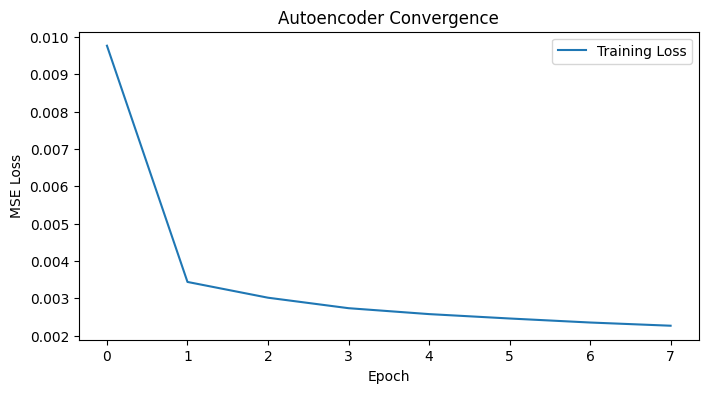

In [5]:
# Plot Loss
plt.figure(figsize=(8, 4))
plt.plot(history, label='Training Loss')
plt.title('Autoencoder Convergence')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()


Extracting features from full dataset...


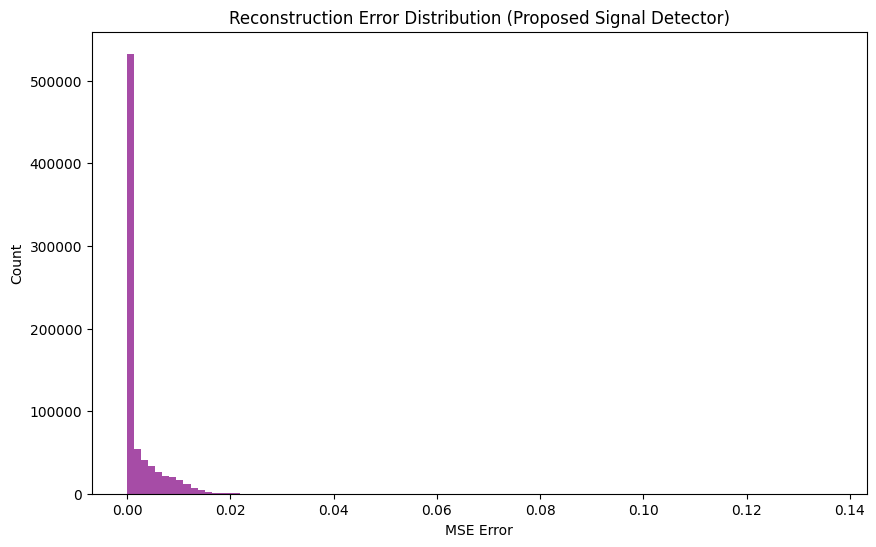

Clustering 774953 samples into 15 groups via KMeans on Latent Space...


/Users/laibanajam/miniconda3/envs/ml/lib/python3.9/site-packages/threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


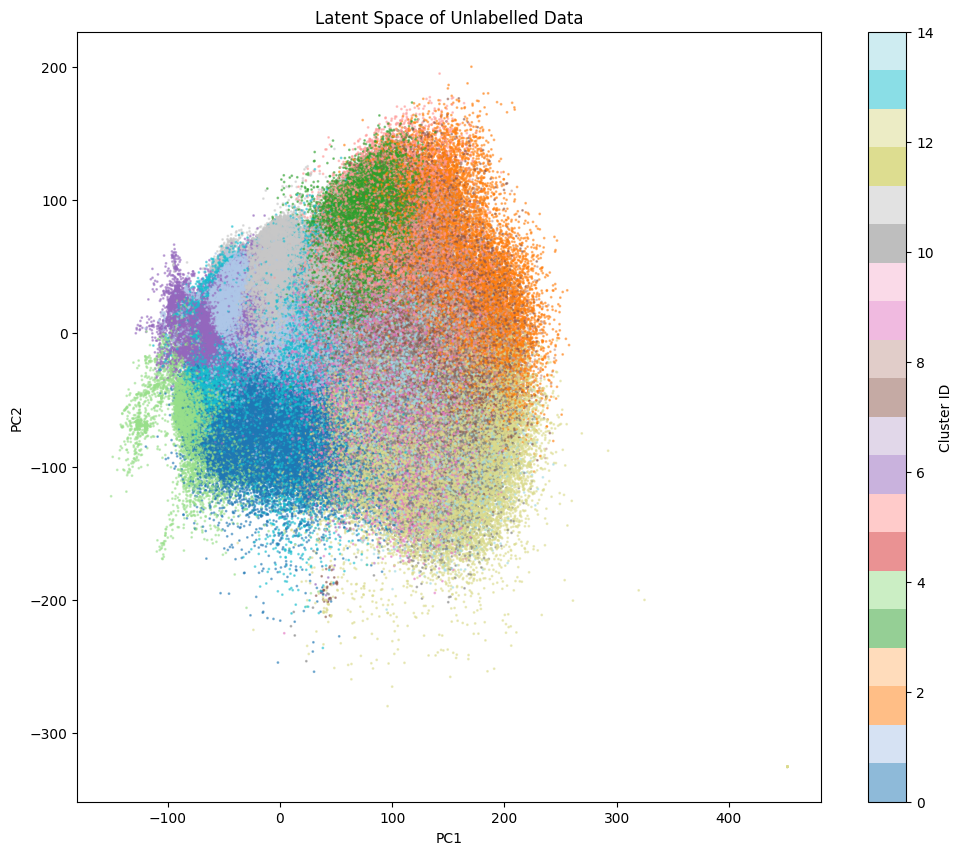

Cluster Counts:
cluster
1     252467
11    128608
4      66180
6      63195
0      50465
12     36944
13     33078
3      22352
9      19079
8      18990
7      17286
2      17063
5      17020
14     16779
10     15447
Name: count, dtype: int64


In [6]:
# 5. Analysis: Feature Extraction & Clustering
print("Extracting features from full dataset...")
model.eval()

# Process in chunks to avoid GPU OOM on large data
eval_loader = DataLoader(TensorDataset(tensor_x), batch_size=Batch_Size, shuffle=False)

latent_vectors = []
reconstruction_errors = []

with torch.no_grad():
    for batch in eval_loader:
        x_batch = batch[0]
        recon, z = model(x_batch)
        
        # Save Features
        latent_vectors.append(z.cpu().numpy())
        
        # Calculate Error per sample (Mean Squared Error per spectrum)
        # Low error = Noise (easy to reconstruct), High error = Signal (complex)
        error = torch.mean((x_batch - recon) ** 2, dim=[1, 2])
        reconstruction_errors.append(error.cpu().numpy())

latent_vectors = np.concatenate(latent_vectors)
reconstruction_errors = np.concatenate(reconstruction_errors)

# Add error to dataframe to find Signal vs Noise
df['recon_error'] = reconstruction_errors

# --- Plot Error Distribution ---
plt.figure(figsize=(10, 6))
plt.hist(reconstruction_errors, bins=100, color='purple', alpha=0.7)
plt.title("Reconstruction Error Distribution (Proposed Signal Detector)")
plt.xlabel("MSE Error")
plt.ylabel("Count")
# Usually a bimodal distribution: Huge peak at low error (Noise) and tail at high error (Signal)
plt.show()

# --- Clustering on Latent Space ---
# We assume similar k=14-20 or use Elbow method if needed. Let's try k=15
k = 15
print(f"Clustering {len(df)} samples into {k} groups via KMeans on Latent Space...")
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(latent_vectors)
df['cluster'] = clusters

# --- Visualize Latent Space (PCA) ---
pca = PCA(n_components=2)
z_2d = pca.fit_transform(latent_vectors)

plt.figure(figsize=(12, 10))
scatter = plt.scatter(z_2d[:,0], z_2d[:,1], c=clusters, cmap='tab20', s=1, alpha=0.5)
plt.colorbar(scatter, label='Cluster ID')
plt.title("Latent Space of Unlabelled Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# --- Summary ---
print("Cluster Counts:")
print(df['cluster'].value_counts())


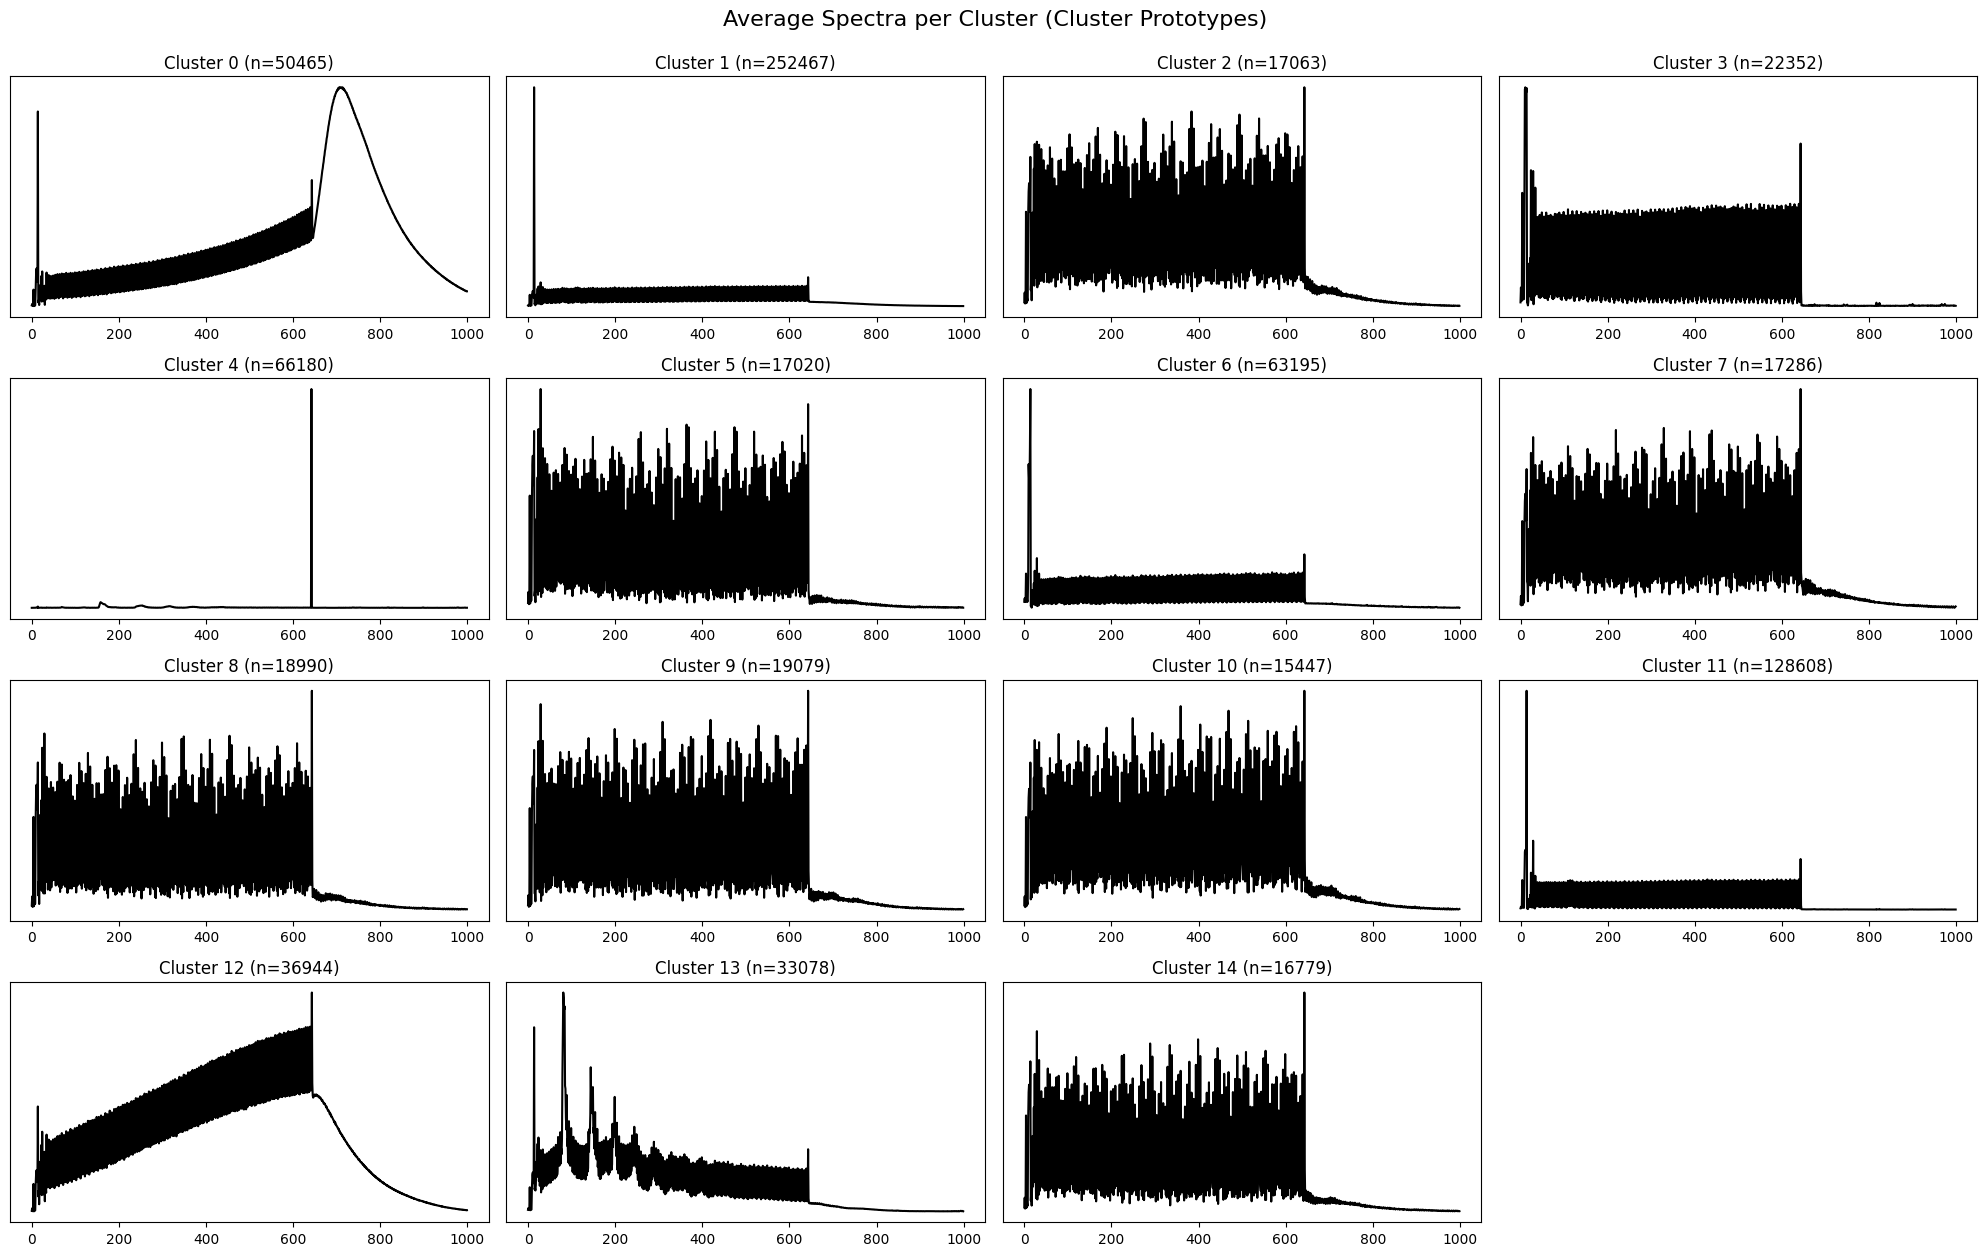

In [7]:
# 6. View Representative Spectra per Cluster
# To understand what the clusters mean without labels, we average the spectra in each cluster
# and plot the result (The "Prototype" for that cluster)

plt.figure(figsize=(20, 15))

unique_clusters = np.sort(df['cluster'].unique())
for i, c_id in enumerate(unique_clusters):
    # Get all indices for this cluster
    indices = df[df['cluster'] == c_id].index
    
    # Get raw spectra (use raw inputs to see real peaks, not reconstructed)
    cluster_spectra = X_train[indices]
    
    # Calculate Mean Spectrum
    mean_spectrum = np.mean(cluster_spectra, axis=0)
    
    # Plot
    plt.subplot(5, 4, i+1) # Adjust grid size based on k
    plt.plot(mean_spectrum, color='black')
    plt.title(f"Cluster {c_id} (n={len(indices)})")
    plt.yticks([]) # Hide Y axis for cleaner look
    
plt.tight_layout()
plt.suptitle("Average Spectra per Cluster (Cluster Prototypes)", y=1.02, fontsize=16)
plt.show()
